# Feature Generation

In [1]:
#pip install plotly

In [2]:
import matplotlib as mpl

# Enable LaTeX-style font
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import scipy.sparse as sp
import json
import zipfile
from scipy.sparse import load_npz
import random
from tqdm import tqdm
#import plotly.express as px
import pandas as pd

In [4]:
url_domains = pd.read_csv('../02_data/top_1000_urls.csv.gz', compression='gzip')

In [5]:
# Load datasets
chats = pd.read_parquet('../02_data/chats.parquet')

# chat_index = np.load('../02_data/chat_index.npy')
# url_domains = pd.read_csv('../02_data/url_domains.csv')
url_domains.info()
domain_pc1 = pd.read_csv('../02_data/domain_pc1.csv')
url_data = pd.read_parquet('../02_data/url.data.parquet')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441779 entries, 0 to 1441778
Data columns (total 18 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   index                1441779 non-null  int64  
 1   url                  1441779 non-null  object 
 2   domain               1441779 non-null  object 
 3   messages             1441779 non-null  int64  
 4   chats                1441779 non-null  int64  
 5   avalanches           1441779 non-null  int64  
 6   mean_avalanche_size  1441779 non-null  float64
 7   top_avalanche_size   1441779 non-null  int64  
 8   virality             1441779 non-null  float64
 9   top_shares_1h        1441779 non-null  int64  
 10  top_shares_6h        1441779 non-null  int64  
 11  top_shares_1d        1441779 non-null  int64  
 12  top_shares_3d        1441779 non-null  int64  
 13  top_shares_14d       1441779 non-null  int64  
 14  first_share_date     1441779 non-null  object 
 15

In [6]:
chat_url_shares = load_npz('../02_data/chat_url_shares.npz')

## Check Embeddings

In [7]:
import gzip

with gzip.open('../02_data/article_embeddings_1000.txt.gz', 'rt') as f:  
    article_embeddings = pd.read_json(f)

In [8]:
#article_embeddings = pd.read_parquet("../02_data/article_embeddings.parquet")

article_embeddings = article_embeddings.rename(columns={'url_index':'index'})
article_embeddings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1091004 entries, 0 to 1091003
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype 
---  ------             --------------    ----- 
 0   index              1091004 non-null  int64 
 1   url                1091004 non-null  object
 2   article            1091004 non-null  object
 3   article_embedding  1091004 non-null  object
dtypes: int64(1), object(3)
memory usage: 33.3+ MB


In [9]:
# Merge article_embeddings with url_domains to get domain
article_embeddings = pd.merge(
    article_embeddings,
    url_domains[['index', 'domain', 'virality', 'avalanches', 'messages', 'chats', 'pc1']],
    on='index',
    how='inner'
).rename(columns={'index': 'url_index'})#, 'embedding':'article_embedding'})

In [10]:
article_embeddings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1086213 entries, 0 to 1086212
Data columns (total 10 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   url_index          1086213 non-null  int64  
 1   url                1086213 non-null  object 
 2   article            1086213 non-null  object 
 3   article_embedding  1086213 non-null  object 
 4   domain             1086213 non-null  object 
 5   virality           1086213 non-null  float64
 6   avalanches         1086213 non-null  int64  
 7   messages           1086213 non-null  int64  
 8   chats              1086213 non-null  int64  
 9   pc1                1086213 non-null  float64
dtypes: float64(2), int64(4), object(4)
memory usage: 82.9+ MB


In [11]:
embeddings = np.vstack(article_embeddings['article_embedding'])
print("Embeddings shape:", embeddings.shape)

Embeddings shape: (1086213, 384)


In [12]:
filtered_df = article_embeddings.loc[article_embeddings['url_index'] < 5000]
filtered_embeddings = np.vstack(filtered_df['article_embedding'])

In [13]:
# Select 5 random domains
random_domains = article_embeddings["domain"].dropna().unique()  # Get unique domains
random_sampled_domains = pd.Series(random_domains).sample(10, random_state=42).tolist()  # Select 5 randomly

# Filter the dataset to include only the selected domains
filtered_df = article_embeddings[article_embeddings["domain"].isin(random_sampled_domains)]

# Stack the embeddings
filtered_embeddings = np.vstack(filtered_df['article_embedding'])

In [14]:
pip install umap-learn

  Using cached pynndescent-0.5.13-py3-none-any.whl.metadata (6.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 2.7 MB/s eta 0:00:00
Using cached pynndescent-0.5.13-py3-none-any.whl (56 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 74.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.1
    Uninstalling scikit-learn-1.3.1:
      Successfully uninstalled scikit-learn-1.3.1
Note: you may need to restart the kernel to use updated packages.


UMAP to reduce the dimensionality of the embeddings to 2D or 3D for visualization, different colors for the scatter plots in order to identify clusters

In [15]:
from umap.umap_ import UMAP
import matplotlib.pyplot as plt

ImportError: cannot import name 'get_tags' from 'sklearn.utils' (/opt/conda/lib/python3.11/site-packages/sklearn/utils/__init__.py)

In [17]:
embeddings = np.vstack(filtered_df['article_embedding'])

In [ ]:
# Assuming `embeddings` is a matrix of shape (n_samples, embedding_dim)
umap_model = UMAP(n_components=2, random_state=42)
low_dim_embeddings = umap_model.fit_transform(filtered_embeddings)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=low_dim_embeddings[:, 0],
    y=low_dim_embeddings[:, 1],
    hue=filtered_df['domain'],  # Replace with the metadata, e.g., domains, labels, etc.
    palette='Paired',
    s=100,
    alpha=0.9
)
#plt.suptitle("UMAP Projection of Article Embeddings", fontsize=18)
#plt.title("10 Random Filtered Domains", fontsize=12)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)

# Hide legend
# plt.legend([], [], frameon=False)
plt.legend(title="Domain", loc="lower right") #, fontsize="big"  bbox_to_anchor=(1.05, 1),

# Export the plot as an image file
plt.savefig("../03_plots/umap_projection.png", dpi=300, bbox_inches="tight")

# Show the plot (optional)
plt.show()


In [ ]:
filtered_df.info()

In [ ]:
from sklearn.metrics import silhouette_score, normalized_mutual_info_score

umap_model = UMAP(n_components=2, random_state=42)
low_dim_embeddings = umap_model.fit_transform(filtered_embeddings)

# Example for silhouette score
sil_score = silhouette_score(low_dim_embeddings, filtered_df['domain'])
print("Silhouette Score:", sil_score)

In [18]:
article_embeddings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1086213 entries, 0 to 1086212
Data columns (total 10 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   url_index          1086213 non-null  int64  
 1   url                1086213 non-null  object 
 2   article            1086213 non-null  object 
 3   article_embedding  1086213 non-null  object 
 4   domain             1086213 non-null  object 
 5   virality           1086213 non-null  float64
 6   avalanches         1086213 non-null  int64  
 7   messages           1086213 non-null  int64  
 8   chats              1086213 non-null  int64  
 9   pc1                1086213 non-null  float64
dtypes: float64(2), int64(4), object(4)
memory usage: 82.9+ MB


## Aggregate Data by Domain

In [19]:
# Filter chat_url_shares to keep only URLs present in article_embeddings
valid_url_indices = article_embeddings['url_index'].values
filtered_chat_url_shares = chat_url_shares.tocsr()[:, valid_url_indices]

In [20]:
valid_url_indices

array([21729958, 21729963, 21729926, ...,  7264090, 50656919, 50656918])

In [21]:
filtered_chat_url_shares

<65338x1086213 sparse matrix of type '<class 'numpy.int64'>'
	with 5081759 stored elements in Compressed Sparse Row format>

In [22]:
article_embeddings.head()

,url_index,url,article,article_embedding,domain,virality,avalanches,messages,chats,pc1
0,21729958,https://kyivindependent.com/military-intellige...,Military intelligence: Special forces land in ...,"[-0.22246763110160803, -0.11443329602479901, -...",kyivindependent.com,0.707107,2,2,2,0.616054
1,21729963,https://www.courier-journal.com/story/news/202...,"Nationwide Emergency Alert Test: US radios, TV...","[0.138708412647247, 0.067714631557464, 0.14795...",courier-journal.com,1.000000,1,1,1,0.841517
2,21729926,https://abc30.com/us-navy-destroyer-red-sea-ho...,US Navy destroyer in Red Sea shoots down cruis...,"[-0.032871142029762004, 0.11436393111944101, 0...",abc30.com,1.000000,1,1,1,0.695942
3,7237129,https://pressefreiheit.rtde.live/international...,Italien will aus Seidenstraßen-Projekt ausstei...,"[0.07064913213253, -0.038502197712659, 0.17695...",rtde.live,0.301511,11,11,1,0.548037
4,21729944,https://www.dailysignal.com/2023/10/11/there-b...,Hamas Issues a 'Call to Arms' in Support of Ga...,"[-0.06996063888072901, 0.32038614153862, -0.02...",dailysignal.com,0.500000,4,4,4,0.472970


In [23]:
# Aggregate based on the selected articles
aggregated_data = article_embeddings.groupby('domain').agg({
    'url_index': lambda x: list(x),
    'article': lambda x: list(x), #lambda x: ' '.join(x),
    'article_embedding': lambda x: np.mean([np.array(ast.literal_eval(e)) if isinstance(e, str) else e for e in x], axis=0),
    'virality': 'mean',
    'avalanches': 'mean',
    'messages': 'mean',
    'chats': 'mean',
    'pc1': 'first'
}).reset_index()

aggregated_data["domain_id"] = range(len(aggregated_data))

aggregated_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6106 entries, 0 to 6105
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   domain             6106 non-null   object 
 1   url_index          6106 non-null   object 
 2   article            6106 non-null   object 
 3   article_embedding  6106 non-null   object 
 4   virality           6106 non-null   float64
 5   avalanches         6106 non-null   float64
 6   messages           6106 non-null   float64
 7   chats              6106 non-null   float64
 8   pc1                6106 non-null   float64
 9   domain_id          6106 non-null   int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 477.2+ KB


In [28]:
import matplotlib.pyplot as plt

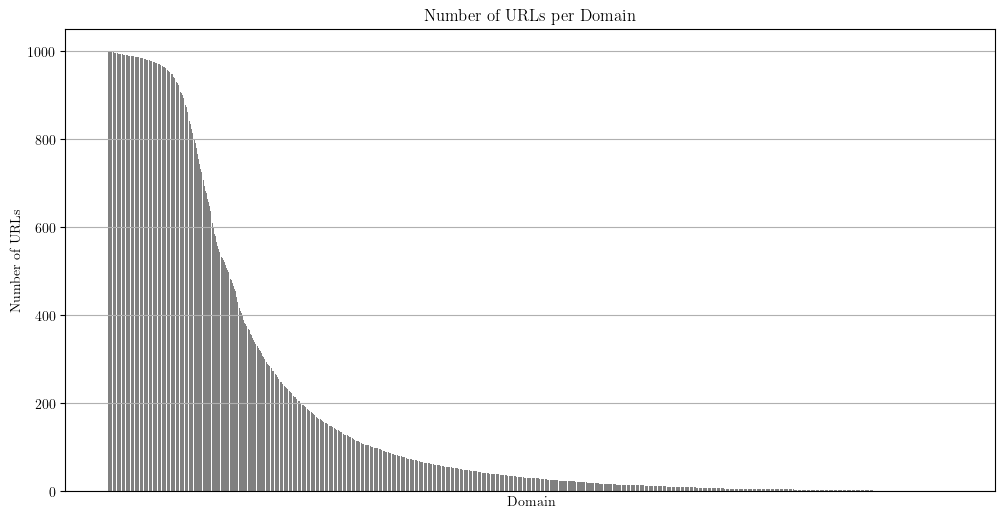

In [29]:
# Add a new column for number of URLs per domain
aggregated_data['num_urls'] = aggregated_data['url_index'].apply(lambda x: len(x))
aggregated_data_sorted = aggregated_data.sort_values(by='num_urls', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(aggregated_data_sorted['domain'], aggregated_data_sorted['num_urls'], color='grey')

plt.xlabel('Domain')
plt.ylabel('Number of URLs')
plt.title('Number of URLs per Domain')

# Hide the x-axis tick labels
plt.xticks([], []) 
plt.grid(axis='y')

plt.savefig('../03_plots/hist_url_per_domain.png')
plt.show()

In [ ]:
# Define thresholds for pc1-based greyscale grouping
threshold1 = 0.33
threshold2 = 0.66

# Add a new column for number of URLs per domain
aggregated_data['num_urls'] = aggregated_data['url_index'].apply(lambda x: len(x))
aggregated_data_sorted = aggregated_data.sort_values(by='num_urls', ascending=False)

# Define greys for each range
def get_grey(pc1):
    if pc1 < threshold1:
        return 'deepskyblue'  # deepskyblue
    elif pc1 < threshold2:
        return '#a6a6a6'  # medium grey
    else:
        return '#4d4d4d'  # dark grey

colors = aggregated_data_sorted['pc1'].apply(get_grey)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(aggregated_data_sorted['domain'], aggregated_data_sorted['num_urls'], color=colors)

plt.xlabel('Domain')
plt.ylabel('Number of URLs')
plt.title('Number of URLs per Domain (Colored by PC1)')

# Hide the x-axis tick labels
plt.xticks([], []) 
plt.grid(axis='y')

# Add legend
light_patch = mpatches.Patch(color='deepskyblue', label='0')
medium_patch = mpatches.Patch(color='#a6a6a6', label='1')
dark_patch = mpatches.Patch(color='#4d4d4d', label='2')
plt.legend(handles=[light_patch, medium_patch, dark_patch], title='PC1 Bins')

plt.savefig('../03_plots/hist_url_per_domain_color.png')
plt.show()


In [ ]:
# Step 1: Count how many domains have each number of URLs
url_distribution = aggregated_data['num_urls'].value_counts().sort_index()

# Step 2: Compute cumulative distribution
cumulative_domains = url_distribution.cumsum()
total_domains = url_distribution.sum()
cumulative_percentage = cumulative_domains / total_domains

# Step 3: Find minimum number of URLs where cumulative percentage >= 0.80
min_urls_for_80_percent = cumulative_percentage[cumulative_percentage > 0.2].index[0]

print(f"Minimum number of URLs that 80% of domains have: {min_urls_for_80_percent}")


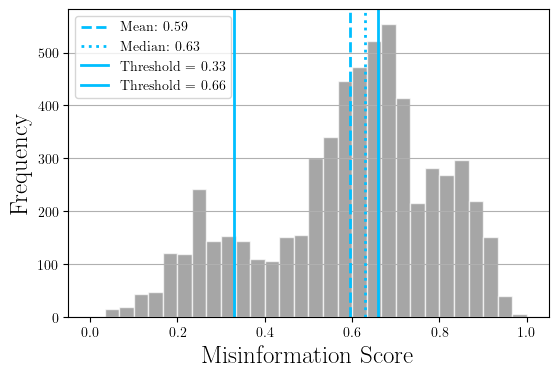

In [35]:
# Compute mean and median
mean_value = aggregated_data['pc1'].mean()
median_value = aggregated_data['pc1'].median()

# Define thresholds
threshold1 = 0.33
threshold2 = 0.66

# Plot histogram
plt.figure(figsize=(6.2, 4))
plt.hist(aggregated_data['pc1'], color='grey', alpha=0.7, edgecolor='white', bins=30)

# Add vertical lines
plt.axvline(mean_value, color='deepskyblue', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.2f}')
plt.axvline(median_value, color='deepskyblue', linestyle=':', linewidth=2, label=f'Median: {median_value:.2f}')
plt.axvline(threshold1, color='deepskyblue', linestyle='-', linewidth=2, label='Threshold = 0.33')
plt.axvline(threshold2, color='deepskyblue', linestyle='-', linewidth=2, label='Threshold = 0.66')

# Customize plot
#plt.title('Distribution of Misinformation Score')
plt.xlabel('Misinformation Score', fontsize=18)
plt.ylabel('Frequency',fontsize=18)
plt.grid(axis='y')
plt.legend()

# Save and show
plt.savefig('../03_plots/hist_pc1.pdf')
plt.show()


In [ ]:
aggregated_data

## Train Test Split

In [ ]:
# Train-test split based on nodes (domains)
unique_domains = aggregated_data['domain'].unique()
train_domains, test_domains = train_test_split(unique_domains, test_size=0.2, random_state=42)

# Split data into train and test sets
train_data = aggregated_data[aggregated_data['domain'].isin(train_domains)]
test_data = aggregated_data[aggregated_data['domain'].isin(test_domains)]

node_features = aggregated_data[['domain_id', 'url_index', 'article', 'domain', 'article_embedding', 'virality', 'avalanches', 'messages', 'chats', 'pc1']].copy()

node_features['domain_id'] = node_features['domain_id'].astype(int)
#node_features['year'] = node_features['year'].astype(int)
#node_features['virality'] = node_features['virality'].round(2)

## Filter Chat URL matrix

In [ ]:
# Mapping
unique_domains = train_data['domain'].dropna().unique()
url_to_domain = article_embeddings.set_index('url')['domain']
domain_to_index_map = train_data.set_index('domain')['domain_id']
#train_data['domain_id'] = article_embeddings['domain'].map(domain_to_index_map)
article_url_map = article_embeddings.set_index('url_index')['url']

In [ ]:
article_url_map

In [ ]:
train_domains_set = set(train_domains)

In [ ]:
# Create edge list from filtered_chat_url_shares with domain indices
rows, cols = chat_url_shares.tocsr().nonzero()
edges = []

for row, col in tqdm(zip(rows, cols), total=len(rows), desc="Processing chat-url pairs"):
    url = article_url_map.get(col, None)  # Get url_id
    if url is not None:
        domain = url_to_domain.get(url, None)  # Map url_id to domain
        if isinstance(domain, pd.Series):
            domain = domain.iloc[0]
        if domain in train_domains_set:  # Only include training domains
            domain_id = domain_to_index_map.get(domain)  # Get index
            if domain_id is not None:
                edges.append((row, domain_id))  # Add valid edge

# Create the filtered edge list DataFrame
train_edge_list = pd.DataFrame(edges, columns=['chat_id', 'domain_id'])

In [ ]:
# Ensure proper integer type
train_edge_list['chat_id'] = train_edge_list['chat_id'].astype(int)
train_edge_list['domain_id'] = train_edge_list['domain_id'].astype(int)

# Print statistics for verification
#print(f"Train Edge List Shape: {train_edge_list.shape}")
print(f"Max domain index: {train_edge_list['domain_id'].max()}")
print(f"Min domain index: {train_edge_list['domain_id'].min()}")

In [ ]:
#train_edge_list = train_edge_list.drop(columns=['domain_id'])

In [ ]:
from scipy.sparse import coo_matrix

chat_domain_shares = coo_matrix(
    (np.ones(len(train_edge_list)), (train_edge_list['chat_id'], train_edge_list['domain_id']))
)

In [ ]:
chat_domain_shares

In [ ]:
node_features

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
# train_sample = train_data.sample(n=100, random_state=42)

# Define outlier thresholds for avalanches
pc1_threshold_high = train_data['pc1'].quantile(0.9999) 
pc1_threshold_low = train_data['pc1'].quantile(0.0001)   
avalanches_threshold_high = train_data['avalanches'].quantile(0.999)  
avalanches_threshold_low = train_data['avalanches'].quantile(0.001)  

# Scatter plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    train_data['pc1'], 
    train_data['avalanches'], 
    alpha=0.3, 
    color='grey', 
    #cmap='BuGn', 
    s=100
)

# Add color bar
#plt.colorbar(sc, label='Avalanches')

# Labeling
plt.xlabel('Misinformation Score')
plt.ylabel('Avalanches')
# plt.title('Avalanches of Domains vs. Misinformation Score')

# Add labels for outliers
for pc1, avalanches, domain in zip(train_data['pc1'], train_data['avalanches'], train_data['domain']):
    if pc1 > pc1_threshold_high or pc1 < pc1_threshold_low or avalanches > avalanches_threshold_high or avalanches < avalanches_threshold_low:
        plt.text(pc1 + 0.02, avalanches, domain, fontsize=9)

ax = plt.gca()
for spine in ['top', 'right']:# 'left', 'bottom'
    ax.spines[spine].set_visible(False)
    
# Save the figure
plt.savefig('../03_plots/sample_scatter_outliers_pc1_avalanches.png')
plt.show()


## Export

In [ ]:
print(train_data.info())
print(test_data.info())
print(train_edge_list.info())

In [ ]:
# Step 5: Save results
train_data.to_csv('../02_data/train_test/train_data.csv', index=False)
test_data.to_csv('../02_data/train_test/test_data.csv', index=False)

In [ ]:
train_edge_list.to_csv('../02_data/train_test/train_edge_list.csv', index=False)

In [ ]:
node_features.to_csv('../02_data/train_test/node_features.csv', index=False)

In [ ]:
# merged_data.info()

In [ ]:
#merged_data = merged_data.drop(columns=['is_english', 'is_social_media'])
# merged_data.to_parquet('../02_data/embeddings_merged.parquet', index=False)